In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants
from mpl_toolkits.mplot3d.axes3d import Axes3D # 3D 
from matplotlib import markers
import matplotlib.ticker as ticker

we try to reproduce this picture  
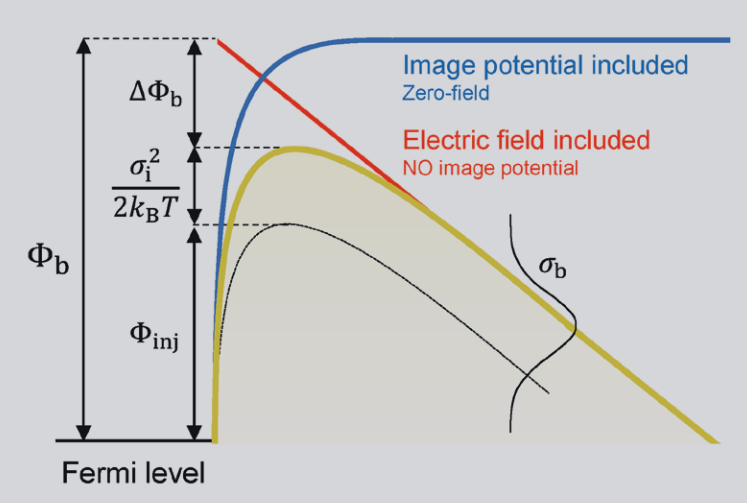

考虑原始注入势垒${\phi}_b$，存在多种组成与修正

## 1. without consider anything

Text(0, 0.5, '${\\Phi}_b(eV)$')

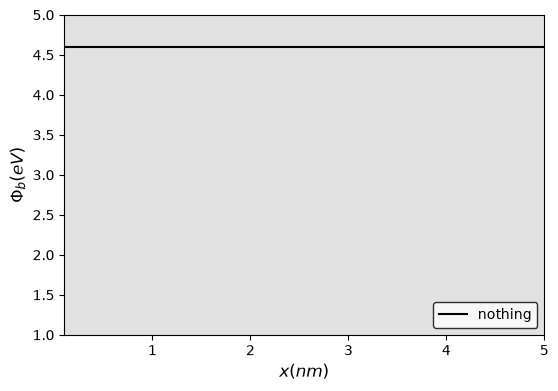

In [3]:
fig=plt.figure(figsize=(6,4),facecolor="#ffffff")#创建画布,6x4英寸,背景白
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height), facecolor="#e1e1e1")
ax.set_xlim(0.1,5)
ax.set_ylim(1, 5)

x = np.linspace(0.1, 5, 100)
y = 4.6 + x*0
ax.plot(x, y, color='black', linewidth=1.5, linestyle='-', label='nothing')
ax.legend(loc=4, fontsize=10, frameon=True, facecolor='white', edgecolor='black')

ax.set_xlabel("$x(nm)$", fontsize=12)
ax.set_ylabel("${\Phi}_b(eV)$", fontsize=12)

## 2. consider image potential without external field
电子刚离开金属的时候,金属内部电子会重新分布。  
从数学上等效于：金属里面出现一个镜像电荷（Image Charge）  
镜像电荷会和电子“一同运动，方向相反”
$$U(x) = -\frac{1}{4\piε} \frac{q^2}{4x} = -\frac{e^2}{16πεx}$$

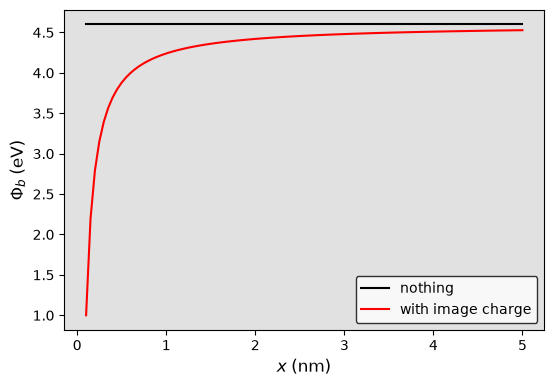

In [4]:
fig = plt.figure(figsize=(6, 4), facecolor="#ffffff")
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height),facecolor="#e1e1e1")


ax.plot(x, y, color='black', linewidth=1.5, linestyle='-', label='nothing')
x_m = x * 1e-9

u1 = scipy.constants.e**2 / (
    16
    * scipy.constants.pi
    * scipy.constants.epsilon_0
    * x_m
)/ scipy.constants.e

y1 = y - u1

ax.plot(x,y1,color='red',linewidth=1.5,label='with image charge')


ax.set_xlabel(r"$x\;(\mathrm{nm})$", fontsize=12)
ax.set_ylabel(r"$\Phi_b\;(\mathrm{eV})$", fontsize=12)
ax.legend(
    loc=4,
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

plt.show()

## 3. consider external field
存在一个外部方向电场
$$U=qV=qFx$$

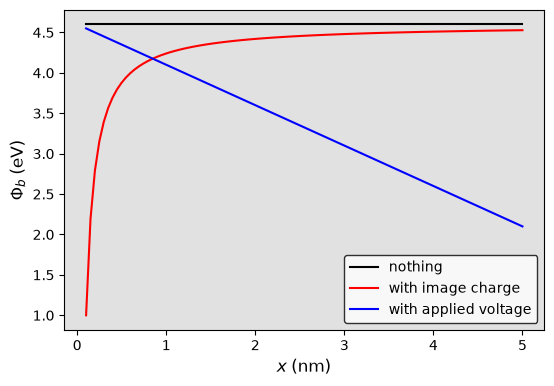

In [5]:
fig = plt.figure(figsize=(6, 4), facecolor="#ffffff")
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height),facecolor="#e1e1e1")

ax.plot(x, y, color='black', linewidth=1.5, linestyle='-', label='nothing')
ax.plot(x,y1,color='red',linewidth=1.5,label='with image charge')

E = 5e8  # V/m
u2_eV = E * x_m
y2 = y - u2_eV
ax.plot(x,y2,color='blue',linewidth=1.5,label='with applied voltage')  

ax.set_xlabel(r"$x\;(\mathrm{nm})$", fontsize=12)
ax.set_ylabel(r"$\Phi_b\;(\mathrm{eV})$", fontsize=12)
ax.legend(
    loc=4,
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)
plt.show()

## 4. combine external field and image potential
$$U(x) =-\frac{e^2}{16πεx} + qV$$

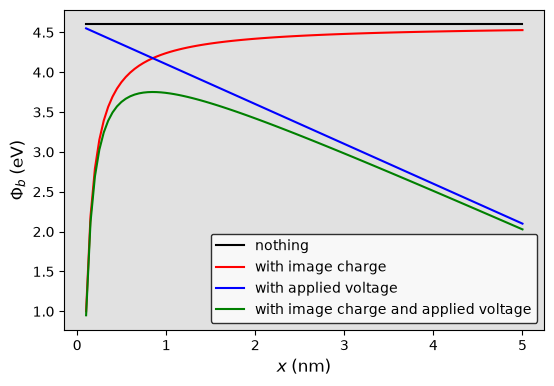

In [6]:
fig = plt.figure(figsize=(6, 4), facecolor="#ffffff")
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height),facecolor="#e1e1e1")

ax.plot(x, y, color='black', linewidth=1.5, linestyle='-', label='nothing')
ax.plot(x,y1,color='red',linewidth=1.5,label='with image charge')
ax.plot(x,y2,color='blue',linewidth=1.5,label='with applied voltage')  

y3 = y - u1 - u2_eV
ax.plot(x,y3,color='green',linewidth=1.5,label='with image charge and applied voltage')

ax.set_xlabel(r"$x\;(\mathrm{nm})$", fontsize=12)
ax.set_ylabel(r"$\Phi_b\;(\mathrm{eV})$", fontsize=12)
ax.legend(
    loc=4,
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)
plt.show()

## 5. consider Gaussian DOS
有效势垒进一步下降：
$$\frac{{\sigma_i}^2}{2k_BT}$$
可被视为某种常数，与材料有关


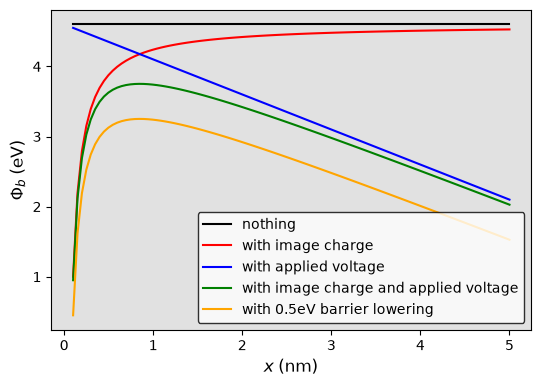

In [7]:
fig = plt.figure(figsize=(6, 4), facecolor="#ffffff")
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height),facecolor="#e1e1e1")

ax.plot(x, y, color='black', linewidth=1.5, linestyle='-', label='nothing')
ax.plot(x,y1,color='red',linewidth=1.5,label='with image charge')
ax.plot(x,y2,color='blue',linewidth=1.5,label='with applied voltage')  
ax.plot(x,y3,color='green',linewidth=1.5,label='with image charge and applied voltage')

y4 = y - u1 - u2_eV - 0.5
ax.plot(x,y4,color='orange',linewidth=1.5,label='with 0.5eV barrier lowering')

ax.set_xlabel(r"$x\;(\mathrm{nm})$", fontsize=12)
ax.set_ylabel(r"$\Phi_b\;(\mathrm{eV})$", fontsize=12)
ax.legend(
    loc=4,
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)
plt.show()

Phi_b = 4.600 eV
Delta Phi_b = 0.849 eV
Disorder term = 0.500 eV
Phi_inj = 3.251 eV


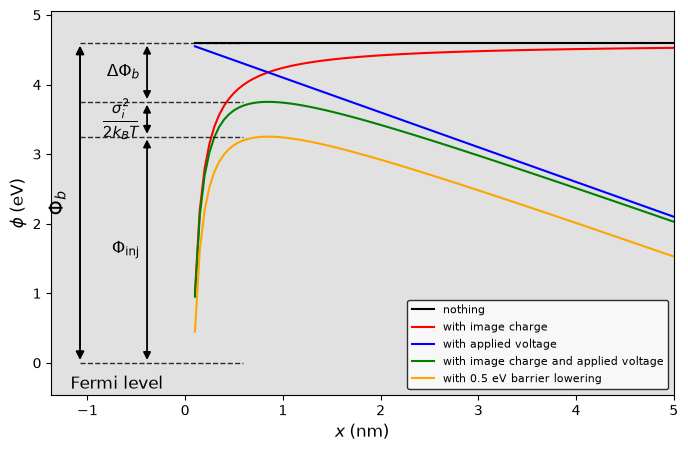

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 假设你前面已经定义：
# x  ：横坐标，单位 nm
# y  ：原始势垒
# y1 ：只有镜像电荷
# y2 ：只有外加电场
# y3 ：镜像电荷 + 外加电场
# u1 ：镜像势能，单位 eV
# u2_eV：外电场势能，单位 eV
# --------------------------------------------------

# 额外的 0.5 eV 势垒降低
y4 = y - u1 - u2_eV - 0.5


fig = plt.figure(figsize=(7.5, 4.8), facecolor="#ffffff")

left, bottom, width, height = 0.12, 0.12, 0.83, 0.80
ax = fig.add_axes(
    (left, bottom, width, height),
    facecolor="#e1e1e1"
)

# ==================================================
# 1. 绘制势垒曲线
# ==================================================

ax.plot(
    x, y,
    color="black",
    linewidth=1.5,
    linestyle="-",
    label="nothing"
)

ax.plot(
    x, y1,
    color="red",
    linewidth=1.5,
    label="with image charge"
)

ax.plot(
    x, y2,
    color="blue",
    linewidth=1.5,
    label="with applied voltage"
)

ax.plot(
    x, y3,
    color="green",
    linewidth=1.5,
    label="with image charge and applied voltage"
)

ax.plot(
    x, y4,
    color="orange",
    linewidth=1.5,
    label="with 0.5 eV barrier lowering"
)


# ==================================================
# 2. 从曲线自动取得标注高度
# ==================================================

fermi_level = 0.0

# 原始势垒高度
phi_b = float(np.max(y))

# 镜像势 + 外电场后的势垒峰值
phi_effective = float(np.max(y3))

# 再降低 0.5 eV 后的注入势垒峰值
phi_inj = float(np.max(y4))

# 防止数值或符号设置造成层级颠倒
phi_effective = min(phi_effective, phi_b)
phi_inj = min(phi_inj, phi_effective)

delta_phi_b = phi_b - phi_effective
disorder_term = phi_effective - phi_inj

print(f"Phi_b = {phi_b:.3f} eV")
print(f"Delta Phi_b = {delta_phi_b:.3f} eV")
print(f"Disorder term = {disorder_term:.3f} eV")
print(f"Phi_inj = {phi_inj:.3f} eV")


# ==================================================
# 3. 给左侧标注预留空间
# ==================================================

x_min = float(np.min(x))
x_max = float(np.max(x))
x_range = x_max - x_min

# 把横轴左端扩展出去
left_boundary = x_min - 0.30 * x_range
ax.set_xlim(left_boundary, x_max)

# 两列箭头位置
x_phi_b = x_min - 0.24 * x_range
x_segments = x_min - 0.10 * x_range

# 虚线从左侧延伸到曲线起始附近
line_left = x_phi_b
line_right = x_min + 0.10 * x_range


# ==================================================
# 4. 水平参考虚线
# ==================================================

for level in [phi_b, phi_effective, phi_inj, fermi_level]:
    ax.hlines(
        y=level,
        xmin=line_left,
        xmax=line_right,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8
    )


# ==================================================
# 5. Φ_b：从 Fermi level 到原始势垒顶部
# ==================================================

ax.annotate(
    "",
    xy=(x_phi_b, phi_b),
    xytext=(x_phi_b, fermi_level),
    arrowprops=dict(
        arrowstyle="<|-|>",
        color="black",
        linewidth=1.4,
        mutation_scale=12
    ),
    annotation_clip=False
)

ax.text(
    x_phi_b - 0.025 * x_range,
    (phi_b + fermi_level) / 2,
    r"$\Phi_b$",
    fontsize=14,
    rotation=90,
    ha="right",
    va="center"
)


# ==================================================
# 6. ΔΦ_b：原始势垒到场致势垒峰值
# ==================================================

if delta_phi_b > 1e-6:
    ax.annotate(
        "",
        xy=(x_segments, phi_b),
        xytext=(x_segments, phi_effective),
        arrowprops=dict(
            arrowstyle="<|-|>",
            color="black",
            linewidth=1.3,
            mutation_scale=11
        ),
        annotation_clip=False
    )

    ax.text(
        x_segments - 0.015 * x_range,
        (phi_b + phi_effective) / 2,
        r"$\Delta\Phi_b$",
        fontsize=12,
        ha="right",
        va="center"
    )


# ==================================================
# 7. σ_i²/(2k_B T)：额外的无序势垒降低
# ==================================================

if disorder_term > 1e-6:
    ax.annotate(
        "",
        xy=(x_segments, phi_effective),
        xytext=(x_segments, phi_inj),
        arrowprops=dict(
            arrowstyle="<|-|>",
            color="black",
            linewidth=1.3,
            mutation_scale=11
        ),
        annotation_clip=False
    )

    ax.text(
        x_segments - 0.015 * x_range,
        (phi_effective + phi_inj) / 2,
        r"$\dfrac{\sigma_i^2}{2k_BT}$",
        fontsize=11,
        ha="right",
        va="center"
    )


# ==================================================
# 8. Φ_inj：从 Fermi level 到最终注入势垒
# ==================================================

ax.annotate(
    "",
    xy=(x_segments, phi_inj),
    xytext=(x_segments, fermi_level),
    arrowprops=dict(
        arrowstyle="<|-|>",
        color="black",
        linewidth=1.3,
        mutation_scale=11
    ),
    annotation_clip=False
)

ax.text(
    x_segments - 0.015 * x_range,
    phi_inj / 2,
    r"$\Phi_{\mathrm{inj}}$",
    fontsize=12,
    ha="right",
    va="center"
)


# ==================================================
# 9. Fermi level
# ==================================================

ax.text(
    x_phi_b - 0.02 * x_range,
    fermi_level - 0.04 * phi_b,
    "Fermi level",
    fontsize=12,
    ha="left",
    va="top"
)


# ==================================================
# 10. 坐标轴和图例
# ==================================================

ax.set_xlabel(
    r"$x\;(\mathrm{nm})$",
    fontsize=12
)

ax.set_ylabel(
    r"$\phi\;(\mathrm{eV})$",
    fontsize=12
)

# 留出一点上下空间
ax.set_ylim(
    fermi_level - 0.10 * phi_b,
    phi_b + 0.10 * phi_b
)

ax.legend(
    loc=4,
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

plt.show()